model training
(Using 5-Fold Cross Validation on Training Data Only)

Tuning Ridge Regression
Tuning Support Vector Regression (SVR)
Tuning Random Forest
Tuning XGBoost

.........................................................
Final comparison (Genuinely Unseen 2026 Test Set)

.........................................................
              Model  MAE (days)  RMSE (days)  R2 Score
1               SVR      2.5263       4.1758    0.1110
2  Ridge Regression      3.0439       4.2429    0.0822
3     Random Forest      3.6463       4.7414   -0.1461
4           XGBoost      4.7519       5.9682   -0.8160

 Packaged complete prediction bundle: [SVR] is 03_best_final_model.pkl

 evaluation plots


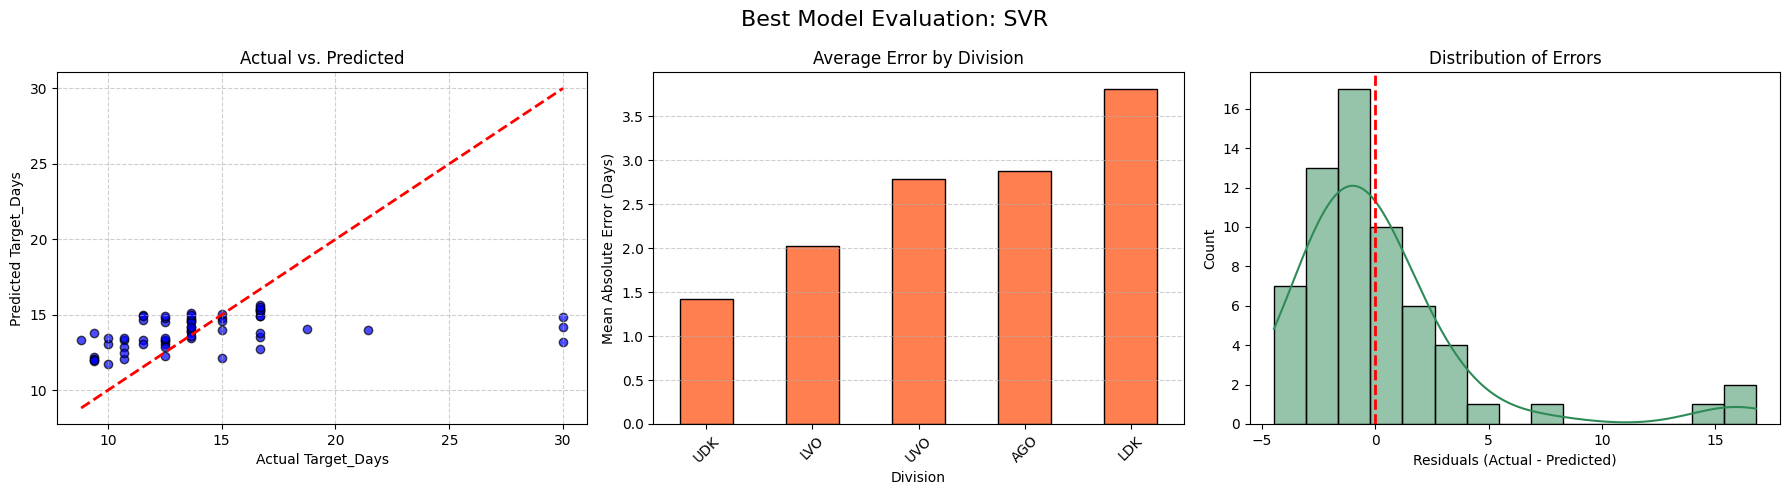

In [4]:
import joblib, time, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler
import xgboost as xgb

BASE = Path(".") 

try:
    data = joblib.load(BASE / "02_preprocessed_data.pkl")
except FileNotFoundError:
    print("Error: 02_preprocessed_data.pkl not found. Please run 02_preprocessing.py first.")
    exit()

X_tr, y_tr, y_tr_n = data['X_tr_clip'], data['y_tr'], data['y_tr_n']
X_te, y_te = data['X_te_clip'], data['y_te']
t_scaler = data['t_scaler']
base_pipe = data['base_pipe']

# Setup Evaluation
cv5 = KFold(n_splits=5, shuffle=True, random_state=42)

def build_pipe(model):
    return Pipeline([
        ("imp", KNNImputer(n_neighbors=5)), 
        ("sc", MinMaxScaler()),
        ("mdl", model)
    ])

def score(name, pipe_model):
    # Predict on test set and inverse transform back to real Days
    yp_n = np.clip(pipe_model.predict(X_te), 0, 1).reshape(-1, 1)
    yp = t_scaler.inverse_transform(yp_n).ravel()
    return {
        "Model": name,
        "MAE (days)":  round(mean_absolute_error(y_te, yp), 4),
        "RMSE (days)": round(np.sqrt(mean_squared_error(y_te, yp)), 4),
        "R2 Score":    round(r2_score(y_te, yp), 4),
        "_mdl":        pipe_model,
        "_preds":      yp
    }

results = []
print("model training")
print("(Using 5-Fold Cross Validation on Training Data Only)\n")

#  MODEL 1: Ridge Regression 
print("Tuning Ridge Regression")
gs_r = GridSearchCV(build_pipe(Ridge(max_iter=10000)),
                    {"mdl__alpha": [1e-4,1e-3,1e-2,0.05,0.1,0.5,1,5,10,50,100,500,1000,5000]},
                    cv=cv5, scoring="neg_mean_absolute_error", n_jobs=-1)
gs_r.fit(X_tr, y_tr_n)
results.append(score("Ridge Regression", gs_r.best_estimator_))

# MODEL 2: Support Vector Regression (SVR)
print("Tuning Support Vector Regression (SVR)")
svr_grid = {"mdl__C":       [0.1,0.5,1,2,5,10,20,50,100,200],
            "mdl__epsilon":  [0.001,0.005,0.01,0.05,0.1,0.2],
            "mdl__gamma":    ["scale","auto",0.01,0.05,0.1,0.5]}
gs_s = GridSearchCV(build_pipe(SVR(kernel="rbf")), svr_grid,
                    cv=cv5, scoring="neg_mean_absolute_error", n_jobs=-1)
gs_s.fit(X_tr, y_tr_n)
results.append(score("SVR", gs_s.best_estimator_))

# MODEL 3: Random Forest
print("Tuning Random Forest")
rf_space = {
    "mdl__n_estimators":      [300,500,700,1000],
    "mdl__max_depth":         [None,6,10,15,20],
    "mdl__min_samples_split": [2,3,5,8],
    "mdl__min_samples_leaf":  [1,2,3],
    "mdl__max_features":      ["sqrt","log2",0.4,0.6],
    "mdl__bootstrap":         [True],
    "mdl__max_samples":       [0.75,0.85,1.0],
}
rs_rf = RandomizedSearchCV(build_pipe(RandomForestRegressor(random_state=42)), rf_space,
                           n_iter=50, cv=cv5, scoring="neg_mean_absolute_error", 
                           random_state=42, n_jobs=-1)
rs_rf.fit(X_tr, y_tr_n)
results.append(score("Random Forest", rs_rf.best_estimator_))

# MODEL 4: XGBoost
print("Tuning XGBoost")
xgb_space = {
    "mdl__n_estimators":      [200,400,800,1500,2000],
    "mdl__max_depth":         [3,4,5,6],
    "mdl__learning_rate":     [0.005, 0.01, 0.03, 0.05, 0.1],
    "mdl__subsample":         [0.55, 0.7, 0.85, 1.0],
    "mdl__colsample_bytree":  [0.5, 0.7, 0.85, 1.0],
    "mdl__min_child_weight":  [1, 3, 5, 7],
    "mdl__gamma":             [0, 0.1, 0.3, 0.5],
    "mdl__reg_alpha":         [0, 0.01, 0.1, 1.0, 5.0],
    "mdl__reg_lambda":        [0.5, 1.0, 2.0, 5.0, 10.0]
}
rs_xgb = RandomizedSearchCV(build_pipe(xgb.XGBRegressor(random_state=42, tree_method="hist", verbosity=0)), 
                            xgb_space, n_iter=60, cv=cv5, scoring="neg_mean_absolute_error", 
                            random_state=42, n_jobs=-1)
rs_xgb.fit(X_tr, y_tr_n)
results.append(score("XGBoost", rs_xgb.best_estimator_))

# Final comparison 
lb = pd.DataFrame([{k:v for k,v in r.items() if not k.startswith("_")} for r in results])
lb = lb.sort_values("MAE (days)").reset_index(drop=True)
lb.index = range(1, len(lb) + 1)

print("\n" + "."*57)
print("Final comparison (Genuinely Unseen 2026 Test Set)")
print("\n" + "."*57)
print(lb.to_string())


# exporting best model
best_name = lb.iloc[0]["Model"]
best_result = next(r for r in results if r["Model"] == best_name)
best_mdl  = best_result["_mdl"]

bundle_out = BASE / "03_best_final_model.pkl"
bundle = {
    "model": best_mdl,
    "target_scaler": data['t_scaler'],
    "clip_lower": data['lo'],
    "clip_upper": data['hi'],
    "numeric_cols": data['num_cols'],
    "leaderboard": lb
}
joblib.dump(bundle, bundle_out)
print(f"\n Packaged complete prediction bundle: [{best_name}] is {bundle_out.name}")

# evaluation metrices
print("\n evaluation plots")
y_pred = best_result["_preds"]

# Reload test data to get the 'Division' column for the bar chart
df26 = pd.read_csv(BASE / "STEMS_Test_2026.csv")
df26 = df26[df26["Near_Pruning_Flag"] == 0].reset_index(drop=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"Best Model Evaluation: {best_name}", fontsize=16)

# Plot 1: Actual vs Predicted
axes[0].scatter(y_te, y_pred, alpha=0.7, color="blue", edgecolors='k')
axes[0].plot([y_te.min(), y_te.max()], [y_te.min(), y_te.max()], "r--", lw=2)
axes[0].set_xlabel("Actual Target_Days")
axes[0].set_ylabel("Predicted Target_Days")
axes[0].set_title("Actual vs. Predicted")
axes[0].grid(True, linestyle="--", alpha=0.6)

# Plot 2: Per-Division MAE
df_results = pd.DataFrame({"Division": df26["Division"], "Actual": y_te, "Predicted": y_pred})
df_results["Error"] = (df_results["Actual"] - df_results["Predicted"]).abs()
div_mae = df_results.groupby("Division")["Error"].mean().sort_values()
div_mae.plot(kind="bar", color="coral", ax=axes[1], edgecolor='k')
axes[1].set_ylabel("Mean Absolute Error (Days)")
axes[1].set_title("Average Error by Division")
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis="y", linestyle="--", alpha=0.6)

# Plot 3: Residual Histogram
residuals = y_te - y_pred
sns.histplot(residuals, bins=15, kde=True, ax=axes[2], color="seagreen")
axes[2].set_xlabel("Residuals (Actual - Predicted)")
axes[2].set_title("Distribution of Errors")
axes[2].axvline(0, color="red", linestyle="--", lw=2)

plt.tight_layout()
plt.savefig(BASE / "evaluation_plots.png", dpi=300)
plt.show()

